Basic Swap Routing

Basic Swap transpiled circuit:


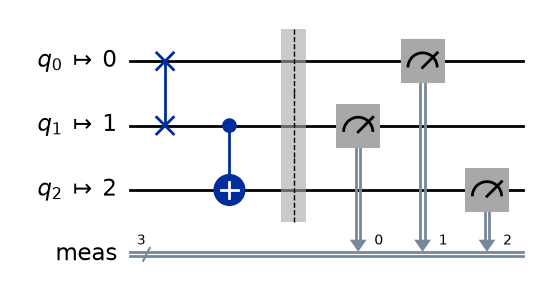

Gate count: OrderedDict({'measure': 3, 'swap': 1, 'cx': 1, 'barrier': 1})
Circuit depth: 3
Measurement results: {'000': 1024}


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from IPython.display import display

coupling_map = CouplingMap([[0, 1], [1, 2]])

qc = QuantumCircuit(3)
qc.cx(0, 2)
qc.measure_all()

qc_basic = transpile(
    qc,
    coupling_map=coupling_map,
    routing_method='basic',
    optimization_level=0
)

print("Basic Swap transpiled circuit:")
display(qc_basic.draw('mpl'))
print(f"Gate count: {qc_basic.count_ops()}")
print(f"Circuit depth: {qc_basic.depth()}")

sim = AerSimulator()
result_basic = sim.run(qc_basic, shots=1024).result()
counts_basic = result_basic.get_counts()
print(f"Measurement results: {counts_basic}")

Lookahead Swap Routing

Lookahead Swap transpiled circuit:


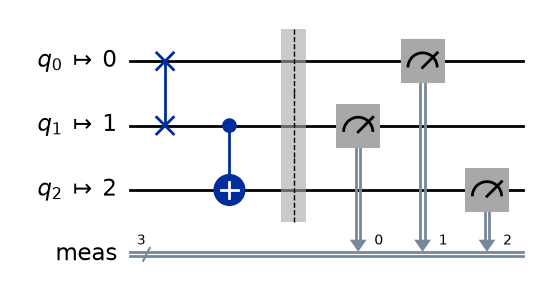

Gate count: OrderedDict({'measure': 3, 'swap': 1, 'cx': 1, 'barrier': 1})
Circuit depth: 3
Measurement results: {'000': 1024}


In [2]:
qc_lookahead = transpile(
    qc,
    coupling_map=coupling_map,
    routing_method='lookahead',
    optimization_level=0
)

print("Lookahead Swap transpiled circuit:")
display(qc_lookahead.draw('mpl'))
print(f"Gate count: {qc_lookahead.count_ops()}")
print(f"Circuit depth: {qc_lookahead.depth()}")

result_lookahead = sim.run(qc_lookahead, shots=1024).result()
counts_lookahead = result_lookahead.get_counts()
print(f"Measurement results: {counts_lookahead}")

Comparing the Two Strategies

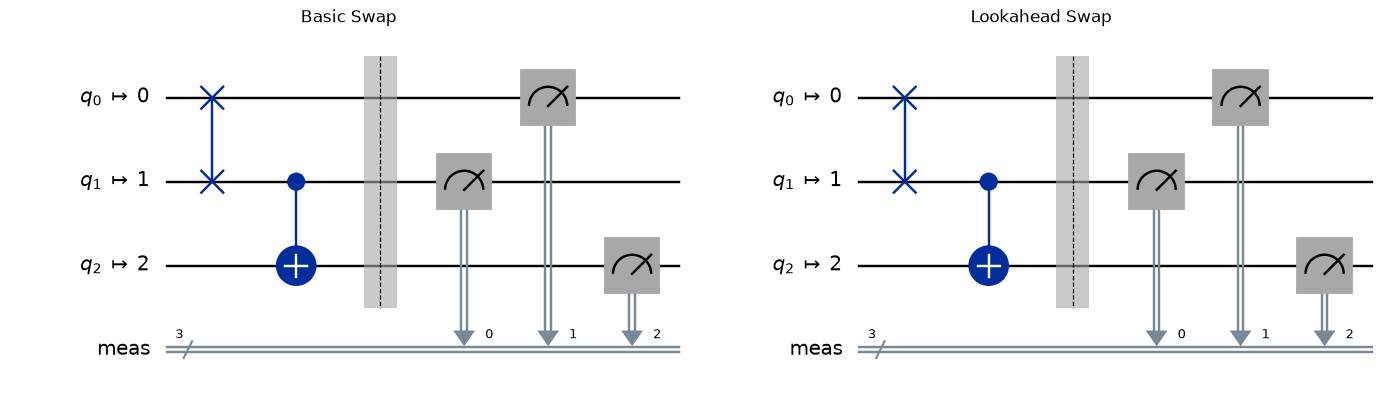

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
qc_basic.draw('mpl', ax=ax1)
ax1.set_title('Basic Swap')
qc_lookahead.draw('mpl', ax=ax2)
ax2.set_title('Lookahead Swap')
plt.tight_layout()
plt.show()